# Full Navier–Stokes PINN for Cone-Plate Inverse Rheology

## Relationship to the companion notebook

`PINN_PowerLaw_Rheology.ipynb` fit (k, n, h0) by assuming the shear rate in the gap is simply
`Omega*r / h(r)` (the standard cone-plate/lubrication shortcut). This notebook replaces that
assumption with an actual **neural velocity field trained against the momentum-balance PDE
residual** — the "full 3D PINN" version of the same inverse problem, as sketched in the closing
section of the companion notebook:

- a small network `v_phi(r, z, Z)` represents the true azimuthal velocity field inside the gap
- it is trained against the **Navier–Stokes momentum residual**, evaluated by autograd at
  randomly sampled collocation points, plus **hard-enforced no-slip boundary conditions** on the
  plate and the rotating cone surface
- `k` and `n` are kept as extra trainable scalars in the *same* loss, so the PDE residual and the
  power-law constitutive law are learned jointly — an **inverse PINN**

## Honest scope of "3D" here

A rotating cone above a fixed plate cannot produce a steady flow that depends on the azimuthal
angle `phi` — that is an exact symmetry of the boundary conditions, not a computational shortcut.
So instead of a network `u_theta(r, phi, z)`, we use `v_phi(r, z)` (conditioned on the sweep
position `Z` too, since `Z` changes the domain shape) and get the same physics for free with a
smaller, faster-to-train network. We also invoke the same **creeping-flow** assumption universal
to rotational rheometry (inertia is negligible for viscous polymer solutions at these speeds), so
the governing equation is the full non-Newtonian **angular-momentum balance**, not the inertial
Navier–Stokes terms. Section 2 derives this explicitly so the simplification is visible, not
hidden. The true fully-general case (`v_r`, `v_z`, non-axisymmetric perturbations, inertia,
transients) is discussed as future work in the final section.

## What you need to have read first

Sections 3 (instrument constants) and the physics setup are shared with the companion notebook.
If anything about `Z_Height_mm`, `Torque_%`, or the cone/plate geometry is unfamiliar, read that
notebook's Sections 1–3 first — this one goes straight to building the PDE-based model.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 100

## 1. Load data and pick demonstration samples

A full PDE-residual PINN is much more expensive to train per sample than the closed-form model
in the companion notebook (seconds vs. roughly a minute of CPU time each, because every training
step needs *second*-order derivatives of the network through autograd). To keep this notebook
runnable end-to-end in a couple of minutes, we demonstrate on **two samples spanning the extremes**
of the dataset: the lowest-viscosity/highest-RPM sweep and the highest-viscosity/lowest-RPM sweep.

Everything below is written as plain reusable functions — looping `DEMO_LABELS` over all 12
`Cell_Label` values instead of 2 is a one-line change if you want the full set (budget roughly
12-15 minutes of CPU time).

In [2]:
df = pd.read_csv("all_PEG.csv")

DEMO_LABELS = ["5%300K_0.577", "10%600K_64.25"]   # low-viscosity/high-RPM and high-viscosity/low-RPM

for label in DEMO_LABELS:
    g = df[df["Cell_Label"] == label]
    print(f"{label:16s}  n_points={len(g):3d}  RPM={g['RPM'].iloc[0]:6.2f}  "
          f"Z range=[{g['Z_Height_mm'].min():.2f}, {g['Z_Height_mm'].max():.2f}] mm")

5%300K_0.577      n_points= 39  RPM= 90.00  Z range=[-66.50, -65.74] mm
10%600K_64.25     n_points= 44  RPM=  0.80  Z range=[-66.34, -65.48] mm


## 2. From Navier–Stokes to a trainable PDE residual

**Setup.** Cylindrical coordinates `(r, phi, z)`, plate at `z=0` (stationary), cone surface at
`z=h(r,Z) = (Z-h0) + r*tan(theta)` (rotating rigidly at `Omega = 2*pi*RPM/60`). By symmetry, the
only nonzero velocity component in steady state is the azimuthal one, `v_phi(r,z)` — no radial or
axial flow, and no dependence on `phi`.

**Constitutive law (what we're solving for).** A generalized Newtonian power-law fluid:

$$\eta(\dot\gamma) = k\,\dot\gamma^{\,n-1}, \qquad \tau_{ij} = \eta(\dot\gamma)\, \dot\gamma_{ij}$$

For this flow, the two nonzero strain-rate components and the effective (second-invariant) shear
rate are:

$$\dot\gamma_{r\phi} = r\,\frac{\partial}{\partial r}\!\left(\frac{v_\phi}{r}\right), \qquad
\dot\gamma_{z\phi} = \frac{\partial v_\phi}{\partial z}, \qquad
\dot\gamma = \sqrt{\dot\gamma_{r\phi}^2 + \dot\gamma_{z\phi}^2}$$

Sanity check against the companion notebook: in the thin-gap limit the network should learn
`v_phi ~ Omega*r*z/h(r)` (nearly linear across the gap), which makes `\dot\gamma_{r\phi} -> 0` and
`\dot\gamma_{z\phi} -> Omega*r/h(r)` — recovering the exact shear rate formula used there. The PDE
below is what lets the network deviate from that simple profile wherever the physics actually
demands it (e.g. where the cone taper term `r*tan(theta)` is not negligible).

**Momentum balance (creeping flow, no pressure gradient in `phi` by symmetry).** This is the
azimuthal component of the Cauchy momentum equation — angular momentum flowing purely by viscous
diffusion, since inertia is negligible at these speeds:

$$\frac{1}{r^2}\frac{\partial (r^2 \tau_{r\phi})}{\partial r} + \frac{\partial \tau_{z\phi}}{\partial z} = 0$$

This is the **residual** we drive to zero via autograd: build `v_phi` from a small network, compute
the strain rates and stresses above (first derivatives), then differentiate the stresses *again*
(second derivatives) to evaluate the left-hand side at randomly sampled points in the gap.

**Boundary conditions**, enforced *exactly* rather than as a soft loss penalty:

$$v_\phi(r, 0) = 0 \quad \text{(no slip at the stationary plate)}, \qquad
v_\phi(r, h(r,Z)) = \Omega r \quad \text{(no slip at the rigidly rotating cone)}$$

## 3. Instrument constants

Same values (and same caveat) as the companion notebook — replace with your spindle's actual
calibration numbers.

In [3]:
TORQUE_FULL_SCALE_DYNE_CM = 7180.0   # given: Torque_% is a percentage of this full-scale torque
CONE_ANGLE_DEG = 2.0                 # TODO: set to your cone spindle's actual half-angle
CONE_RADIUS_MM = 24.0                # TODO: set to your cone spindle's actual radius

TAN_THETA = math.tan(math.radians(CONE_ANGLE_DEG))
R_CONE_M = CONE_RADIUS_MM / 1000.0
R_MIN_M = 5e-4   # keep collocation points off the singular cone apex at r=0

## 4. A fast baseline fit, used only to warm-start the PINN

The PDE-residual PINN below is trained by gradient descent from scratch just like any neural
network, and its (k, n, h0) parameters are just as arbitrary at initialization. Because the
dataset spans RPM = 0.8 to 90 and viscosities across two orders of magnitude, starting every
sample from the *same* neutral guess makes the low-RPM/high-viscosity samples converge far too
slowly (they need k roughly 30x larger than the high-RPM samples).

The fix is simple and standard practice for PINNs: reuse the companion notebook's cheap
closed-form model (which fits in about a second) to get a rough (k, n, h0), and initialize the
PINN's trainable parameters from that instead of a blind guess. The PDE-residual training below
still does all the real work of refining these values against the full physics — this only picks
a sensible starting point.

In [4]:
def baseline_torque_percent(Z_mm, rpm, log_k, raw_n, raw_offset, z_min_mm, n_quad=60):
    # Same closed-form thin-gap model as the companion notebook - used only to get a fast,
    # rough starting point for the PINN below.
    k = F.softplus(log_k) + 1e-6
    n = 0.2 + 1.8 * torch.sigmoid(raw_n)
    h0_mm = z_min_mm - F.softplus(raw_offset) - 0.05
    omega = 2 * torch.pi * rpm / 60.0
    r_m = torch.linspace(1e-6, R_CONE_M, n_quad)
    gap_offset_m = (Z_mm.unsqueeze(-1) - h0_mm) / 1000.0
    h_m = gap_offset_m + r_m * TAN_THETA
    shear_rate = omega * r_m / h_m
    tau = k * shear_rate**n
    dM_dr = 2 * torch.pi * r_m**2 * tau
    torque_Nm = torch.trapz(dM_dr, r_m, dim=-1)
    torque_dyne_cm = torque_Nm * 1e7
    return torque_dyne_cm / TORQUE_FULL_SCALE_DYNE_CM * 100.0, k, n, h0_mm


def fit_baseline(Z_mm, y, rpm, n_epochs=1500, lr=0.05):
    z_min_mm = Z_mm.min()
    log_k = torch.nn.Parameter(torch.tensor(0.0))
    raw_n = torch.nn.Parameter(torch.tensor(0.0))
    raw_offset = torch.nn.Parameter(torch.tensor(0.0))
    opt = torch.optim.Adam([log_k, raw_n, raw_offset], lr=lr)
    for _ in range(n_epochs):
        opt.zero_grad()
        y_pred, k, n, h0 = baseline_torque_percent(Z_mm, rpm, log_k, raw_n, raw_offset, z_min_mm)
        loss = torch.mean((y_pred - y) ** 2)
        loss.backward()
        opt.step()
    return {"k": k.item(), "n": n.item(), "h0_mm": h0.item(), "loss": loss.item()}

## 5. Neural velocity field with hard-enforced boundary conditions

`velocity(...)` maps `(r, z, Z)` to `v_phi`. Rather than adding a boundary-condition loss term
(which then has to be weighted against the PDE and data losses — a common source of PINN training
instability), the boundary conditions are baked directly into the output formula:

$$v_\phi(r,z,Z) = \Omega r \zeta + \zeta(1-\zeta)\cdot v_{scale}\cdot \text{NN}(r,\zeta,Z), \qquad \zeta = z/h(r,Z)$$

At `zeta=0` (the plate) and `zeta=1` (the cone) the `zeta(1-zeta)` factor is exactly zero, so
`v_phi` exactly equals `0` and `Omega*r` there *no matter what the network outputs* — the network
only ever has to learn the *shape* of the profile in between.

In [5]:
class VelocityNet(nn.Module):
    # Small MLP representing the correction to solid-body rotation inside the gap.
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def gap_m(r_m, Z_mm, h0_mm):
    # Local cone-plate gap (meters) at radius r_m, spindle position Z_mm, true zero h0_mm.
    return (Z_mm - h0_mm) / 1000.0 + r_m * TAN_THETA


def velocity(net, r_m, z_m, Z_mm, h0_mm, omega, Z_mid, Z_span):
    # v_phi(r, z, Z) with the no-slip boundary conditions built into the formula itself.
    h = gap_m(r_m, Z_mm, h0_mm)
    zeta = z_m / h
    x = torch.stack([r_m / R_CONE_M, zeta, (Z_mm - Z_mid) / Z_span], dim=-1)
    correction = net(x)
    v_scale = omega * R_CONE_M
    return omega * r_m * zeta + zeta * (1 - zeta) * v_scale * correction

## 6. The PDE residual, computed with autograd

`shear_stresses` implements the constitutive law from Section 2. `pde_residual` differentiates
those stresses *again* (a genuine second-order PINN residual) to evaluate the momentum balance.
Because `k`, `n`, and `h0` vary enormously across samples (RPM 0.8 to 90), the raw residual's
magnitude does too — dividing by the local stress scale keeps the loss around order 1 for every
sample without retuning a loss weight each time.

In [6]:
def grad(y, x):
    # d(y)/d(x) via autograd, keeping the graph so we can differentiate again below.
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]


def shear_stresses(net, r_m, z_m, Z_mm, h0_mm, k, n, omega, Z_mid, Z_span):
    # Power-law shear stresses from the two nonzero strain-rate components of a purely
    # azimuthal flow: gamma_rphi = r * d(v/r)/dr, gamma_zphi = dv/dz.
    V = velocity(net, r_m, z_m, Z_mm, h0_mm, omega, Z_mid, Z_span)
    v_r = grad(V, r_m)
    v_z = grad(V, z_m)
    gamma_r = v_r - V / r_m
    gamma_z = v_z
    gamma_eff = torch.sqrt(gamma_r**2 + gamma_z**2 + 1e-12)
    eta = k * gamma_eff ** (n - 1)   # power-law apparent viscosity
    tau_r = eta * gamma_r
    tau_z = eta * gamma_z
    return tau_r, tau_z


def pde_residual(net, r_m, z_m, Z_mm, h0_mm, k, n, omega, Z_mid, Z_span):
    # Steady axisymmetric angular-momentum balance:
    #   (1/r^2) d(r^2 tau_rphi)/dr + d(tau_zphi)/dz = 0
    # Should be ~0 everywhere in the gap for a physically consistent velocity field.
    r_m = r_m.clone().requires_grad_(True)
    z_m = z_m.clone().requires_grad_(True)
    tau_r, tau_z = shear_stresses(net, r_m, z_m, Z_mm, h0_mm, k, n, omega, Z_mid, Z_span)
    dtau_r_dr = grad(tau_r, r_m)
    dtau_z_dz = grad(tau_z, z_m)
    residual = 2 * tau_r / r_m + dtau_r_dr + dtau_z_dz
    # normalize by the local stress/length scale so one loss weight works across samples
    # with very different k, n, RPM instead of retuning it per sample
    scale = (torch.abs(tau_r) + torch.abs(tau_z)) / R_CONE_M + 1e-3
    return residual / scale

## 7. Torque from the field: the data-loss term

To connect the velocity field back to the measurements, integrate the wall shear stress the
network predicts at the cone surface (`z = h(r,Z)`) over the cone face — exactly the same torque
integral used in the companion notebook, just with the PINN's actual near-wall stress gradient
in place of the closed-form shear-rate formula.

In [7]:
def predicted_torque_percent(net, Z_query_mm, h0_mm, k, n, omega, Z_mid, Z_span, n_quad=24):
    r_1d = torch.linspace(R_MIN_M, R_CONE_M, n_quad)
    Z_b = Z_query_mm.unsqueeze(-1).expand(-1, n_quad).reshape(-1)
    r_b = r_1d.repeat(Z_query_mm.shape[0]).clone().requires_grad_(True)
    h_b = gap_m(r_b, Z_b, h0_mm).detach()
    z_b = h_b.clone().requires_grad_(True)      # evaluate exactly at the cone surface (the wall)
    _, tau_z = shear_stresses(net, r_b, z_b, Z_b, h0_mm, k, n, omega, Z_mid, Z_span)
    dM_dr = (2 * torch.pi * r_b**2 * tau_z).reshape(Z_query_mm.shape[0], n_quad)
    r_grid = r_1d.detach().reshape(1, n_quad).expand(Z_query_mm.shape[0], n_quad)
    torque_Nm = torch.trapz(dM_dr, r_grid, dim=-1)
    return torque_Nm * 1e7 / TORQUE_FULL_SCALE_DYNE_CM * 100.0

## 8. Joint training: network weights + (k, n, h0) together

Total loss = data loss (measured vs. predicted `Torque_%`) + a **PDE loss** (mean squared
residual from Section 6, at freshly-sampled random points in the gap every epoch). The PDE loss
weight is ramped in gradually over the first `ramp_epochs` steps ("curriculum learning") rather
than applied at full strength immediately — this avoids the PDE term dominating early training
before the network has learned even roughly the right velocity scale, which in testing caused the
optimizer to oscillate instead of converge.

In [8]:
def inv_softplus(y):
    return math.log(math.expm1(max(y, 1e-6)))


def inv_sigmoid(p):
    p = min(max(p, 1e-4), 1 - 1e-4)
    return math.log(p / (1 - p))


def train_pinn(label, n_collocation=300, n_epochs=2000, lr=1e-3, phys_weight=0.02,
               ramp_epochs=500, verbose=True):
    g = df[df["Cell_Label"] == label].sort_values("Z_Height_mm")
    Z_data = torch.tensor(g["Z_Height_mm"].values, dtype=torch.float32)
    y_data = torch.tensor(g["Torque_%"].values, dtype=torch.float32)
    rpm = float(g["RPM"].iloc[0])
    omega = 2 * torch.pi * rpm / 60.0
    Z_mid = Z_data.mean()
    Z_span = (Z_data.max() - Z_data.min()) / 2 + 1e-6

    # --- warm start from the fast closed-form model (Section 4) ------------------------
    baseline = fit_baseline(Z_data, y_data, rpm)
    log_k = nn.Parameter(torch.tensor(inv_softplus(baseline["k"])))
    raw_n = nn.Parameter(torch.tensor(inv_sigmoid((baseline["n"] - 0.2) / 1.8)))
    raw_offset = nn.Parameter(torch.tensor(
        inv_softplus(float(Z_data.min()) - baseline["h0_mm"] - 0.05)))

    net = VelocityNet()
    params = list(net.parameters()) + [log_k, raw_n, raw_offset]
    opt = torch.optim.Adam(params, lr=lr)

    history = {"loss_data": [], "loss_phys": [], "k": [], "n": [], "h0_mm": []}
    for epoch in range(n_epochs):
        opt.zero_grad()
        k = F.softplus(log_k) + 1e-6
        n = 0.2 + 1.8 * torch.sigmoid(raw_n)
        h0_mm = Z_data.min() - F.softplus(raw_offset) - 0.05

        # fresh random collocation points every epoch -> physics loss over the WHOLE domain,
        # not just where we happen to have measurements
        r_f = torch.rand(n_collocation) * (R_CONE_M - R_MIN_M) + R_MIN_M
        Z_f = torch.rand(n_collocation) * (Z_data.max() - Z_data.min()) + Z_data.min()
        h_f = gap_m(r_f, Z_f, h0_mm).detach()
        z_f = torch.rand(n_collocation) * h_f

        residual = pde_residual(net, r_f, z_f, Z_f, h0_mm, k, n, omega, Z_mid, Z_span)
        loss_phys = torch.mean(residual**2)

        y_pred = predicted_torque_percent(net, Z_data, h0_mm, k, n, omega, Z_mid, Z_span)
        loss_data = torch.mean((y_pred - y_data) ** 2)

        w = phys_weight * min(1.0, epoch / ramp_epochs)
        loss = loss_data + w * loss_phys
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 5.0)
        opt.step()

        history["loss_data"].append(loss_data.item())
        history["loss_phys"].append(loss_phys.item())
        history["k"].append(k.item()); history["n"].append(n.item()); history["h0_mm"].append(h0_mm.item())

        if verbose and epoch % 400 == 0:
            print(f"  epoch {epoch:5d}  loss_data={loss_data.item():8.3f}  "
                  f"loss_phys={loss_phys.item():8.3f}  k={k.item():8.4f}  "
                  f"n={n.item():.3f}  h0={h0_mm.item():.3f} mm")

    y_pred = predicted_torque_percent(net, Z_data, h0_mm, k, n, omega, Z_mid, Z_span)
    return {
        "label": label, "net": net, "rpm": rpm, "omega": omega,
        "Z_mid": Z_mid, "Z_span": Z_span, "baseline": baseline,
        "k": k.item(), "n": n.item(), "h0_mm": h0_mm.item(),
        "Z_data": Z_data.numpy(), "y_data": y_data.numpy(), "y_pred": y_pred.detach().numpy(),
        "history": history,
    }

In [9]:
pinn_results = {}
for label in DEMO_LABELS:
    print(f"\n=== {label} ===")
    pinn_results[label] = train_pinn(label)


=== 5%300K_0.577 ===


  epoch     0  loss_data=  40.197  loss_phys= 464.621  k=  0.3442  n=0.752  h0=-67.682 mm


  epoch   400  loss_data=   0.133  loss_phys=   8.105  k=  0.3450  n=0.756  h0=-67.651 mm


  epoch   800  loss_data=   0.074  loss_phys=   5.589  k=  0.3425  n=0.755  h0=-67.631 mm


  epoch  1200  loss_data=   0.083  loss_phys=   4.643  k=  0.3413  n=0.754  h0=-67.619 mm


...

  epoch     0  loss_data=  22.405  loss_phys=67833.188  k= 11.7543  n=0.944  h0=-66.396 mm


  epoch   400  loss_data=   2.167  loss_phys=  41.837  k= 11.7510  n=0.919  h0=-66.396 mm


  epoch   800  loss_data=   1.991  loss_phys= 119.922  k= 11.7527  n=0.904  h0=-66.396 mm


  epoch  1200  loss_data=   1.813  loss_phys=  13.890  k= 11.7605  n=0.892  h0=-66.397 mm


  epoch  1600  loss_data=   1.742  loss_phys=  15.946  k= 11.7789  n=0.882  h0=-66.397 mm


## 9. Results

**Training curves** — both loss terms should settle down together. If the data loss drops but the
PDE loss stays high, the network is fitting the measurements without respecting the physics (a
sign the PDE weight is too low or the network has too much unconstrained freedom).

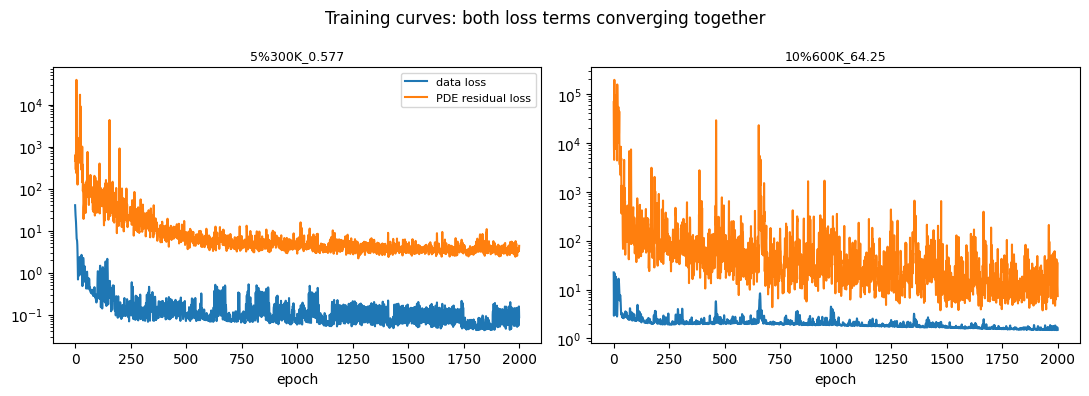

In [10]:
fig, axes = plt.subplots(1, len(DEMO_LABELS), figsize=(11, 4))
axes = np.atleast_1d(axes)
for ax, label in zip(axes, DEMO_LABELS):
    h = pinn_results[label]["history"]
    ax.plot(h["loss_data"], label="data loss")
    ax.plot(h["loss_phys"], label="PDE residual loss")
    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    ax.set_title(label, fontsize=9)
axes[0].legend(fontsize=8)
fig.suptitle("Training curves: both loss terms converging together")
plt.tight_layout()
plt.show()

**Fitted torque curves** — measured data vs. the PINN's prediction (obtained by integrating its
learned wall-stress field, not by any direct curve fit).

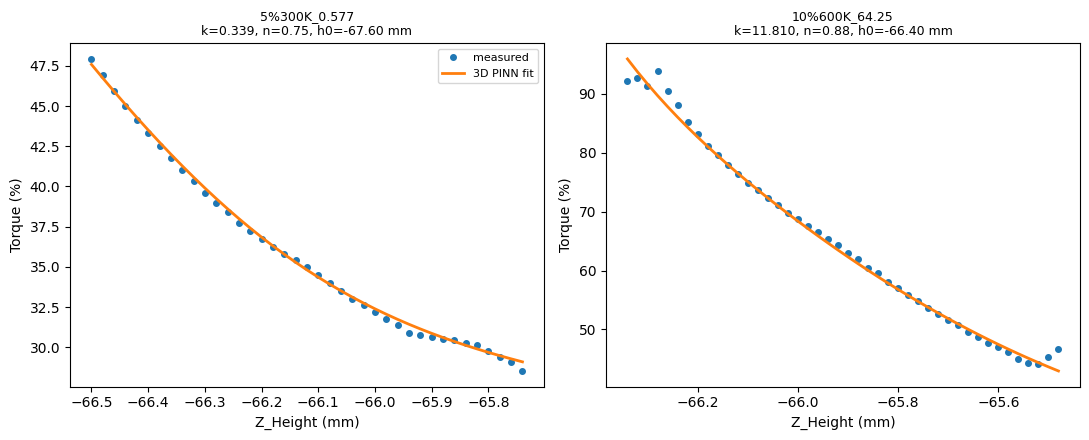

In [11]:
fig, axes = plt.subplots(1, len(DEMO_LABELS), figsize=(11, 4.5))
axes = np.atleast_1d(axes)
for ax, label in zip(axes, DEMO_LABELS):
    r = pinn_results[label]
    order = np.argsort(r["Z_data"])
    ax.plot(r["Z_data"][order], r["y_data"][order], "o", ms=4, label="measured")
    ax.plot(r["Z_data"][order], r["y_pred"][order], "-", lw=2, label="3D PINN fit")
    ax.set_title(f"{label}\nk={r['k']:.3f}, n={r['n']:.2f}, h0={r['h0_mm']:.2f} mm", fontsize=9)
    ax.set_xlabel("Z_Height (mm)")
    ax.set_ylabel("Torque (%)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Baseline vs. PINN** — how far the full PDE-residual fit moved the parameters from the
closed-form warm start. Close agreement is a sanity check that both models are seeing the same
physics; a real difference indicates the closed-form thin-gap shortcut was leaving something out.

In [12]:
rows = []
for label in DEMO_LABELS:
    r = pinn_results[label]
    rows.append({
        "label": label, "rpm": r["rpm"],
        "k_baseline": r["baseline"]["k"], "k_pinn": r["k"],
        "n_baseline": r["baseline"]["n"], "n_pinn": r["n"],
        "h0_baseline_mm": r["baseline"]["h0_mm"], "h0_pinn_mm": r["h0_mm"],
    })
pd.DataFrame(rows)

,label,rpm,k_baseline,k_pinn,n_baseline,n_pinn,h0_baseline_mm,h0_pinn_mm
0,5%300K_0.577,90.0,0.344186,0.339113,0.752087,0.752793,-67.681763,-67.603058
1,10%600K_64.25,0.8,11.754310,11.810114,0.943729,0.876145,-66.395515,-66.397682


## 10. Field diagnostics: what the network actually learned

Unlike the closed-form model, the PINN gives us the *entire* velocity, shear-rate, and residual
field inside the gap — not just the torque it produces. Plotted at the deepest point of each
sweep (the smallest, most informative gap):

- **velocity** should vary smoothly from `0` at `zeta=0` to `Omega*r` at `zeta=1`
- **shear rate** should be highest at the outer radius (largest `r`) and near the cone surface
- **PDE residual** should be small and unstructured everywhere — a large, spatially coherent
  residual (e.g. concentrated near the cone tip) would flag where the physics assumptions are
  breaking down

In [13]:
def field_diagnostics(result, n_r=50, n_zeta=50):
    net = result["net"]
    k = torch.tensor(result["k"]); n = torch.tensor(result["n"])
    h0_mm = torch.tensor(result["h0_mm"]); omega = result["omega"]
    Z_mid = result["Z_mid"]; Z_span = result["Z_span"]
    Z_plot = float(result["Z_data"].min())   # deepest point of the sweep

    r_1d = torch.linspace(R_MIN_M, R_CONE_M, n_r)
    zeta_1d = torch.linspace(0.02, 0.98, n_zeta)   # stay off the BC lines for a cleaner residual map
    r_grid, zeta_grid = torch.meshgrid(r_1d, zeta_1d, indexing="ij")
    r_plain = r_grid.reshape(-1)
    Z_plain = torch.full_like(r_plain, Z_plot)
    z_plain = zeta_grid.reshape(-1) * gap_m(r_plain, Z_plain, h0_mm)

    r_leaf = r_plain.clone().requires_grad_(True)
    z_leaf = z_plain.clone().requires_grad_(True)
    V = velocity(net, r_leaf, z_leaf, Z_plain, h0_mm, omega, Z_mid, Z_span)
    tau_r, tau_z = shear_stresses(net, r_leaf, z_leaf, Z_plain, h0_mm, k, n, omega, Z_mid, Z_span)
    gamma_eff = (torch.sqrt(tau_r**2 + tau_z**2 + 1e-12) / k) ** (1.0 / n)

    residual = pde_residual(net, r_plain, z_plain, Z_plain, h0_mm, k, n, omega, Z_mid, Z_span)

    shape = (n_r, n_zeta)
    return {
        "r_mm": r_grid.numpy() * 1000,
        "zeta": zeta_grid.numpy(),
        "v_phi": V.detach().reshape(shape).numpy(),
        "gamma_eff": gamma_eff.detach().reshape(shape).numpy(),
        "residual": residual.detach().reshape(shape).numpy(),
        "Z_plot_mm": Z_plot,
    }

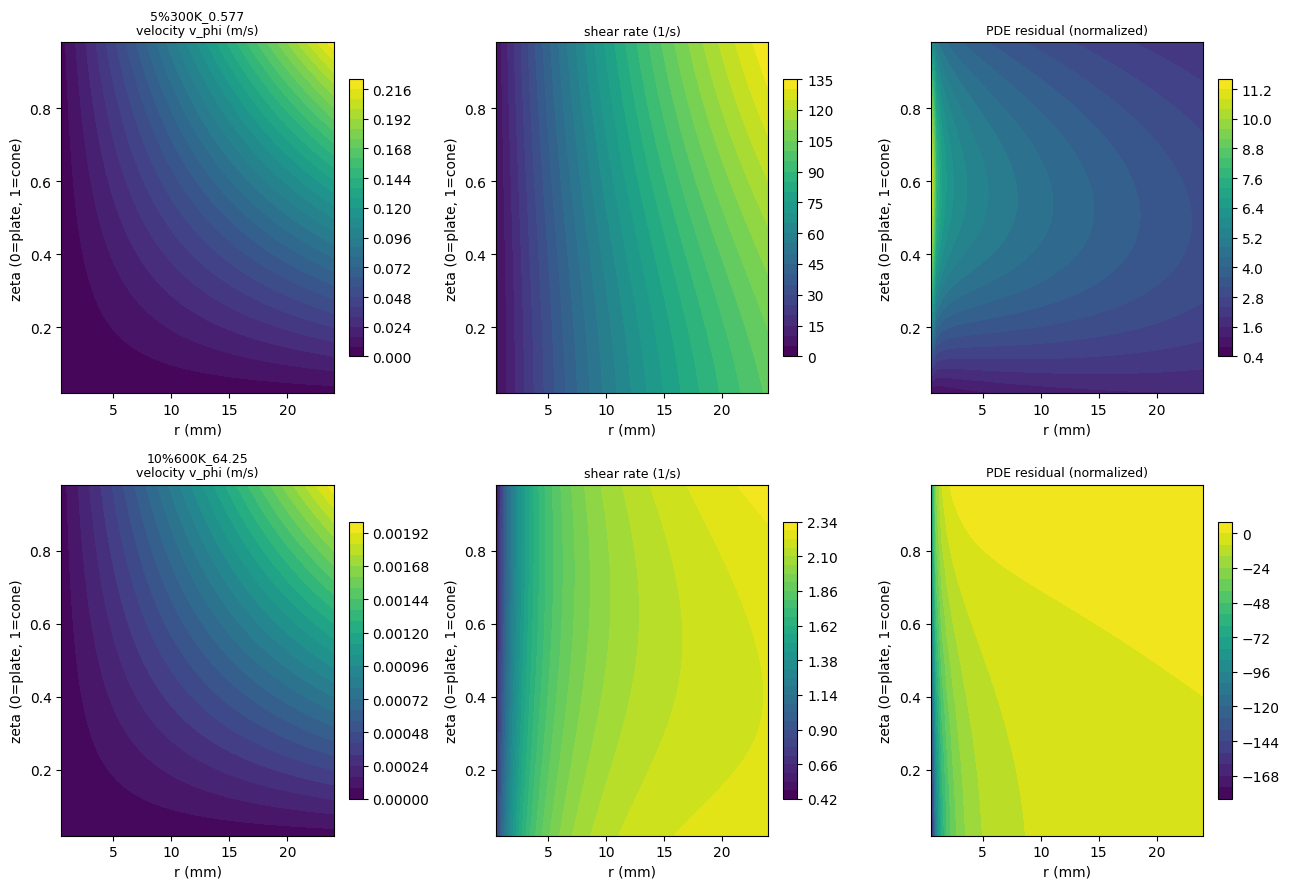

In [14]:
fig, axes = plt.subplots(len(DEMO_LABELS), 3, figsize=(13, 4.5 * len(DEMO_LABELS)))
axes = np.atleast_2d(axes)

titles = ["velocity v_phi (m/s)", "shear rate (1/s)", "PDE residual (normalized)"]
for row, label in enumerate(DEMO_LABELS):
    diag = field_diagnostics(pinn_results[label])
    fields = [diag["v_phi"], diag["gamma_eff"], diag["residual"]]
    for col, (title, field) in enumerate(zip(titles, fields)):
        ax = axes[row, col]
        cs = ax.contourf(diag["r_mm"], diag["zeta"], field, levels=30, cmap="viridis")
        fig.colorbar(cs, ax=ax, fraction=0.046)
        ax.set_xlabel("r (mm)")
        ax.set_ylabel("zeta (0=plate, 1=cone)")
        ax.set_title(f"{label}\n{title}" if col == 0 else title, fontsize=9)

plt.tight_layout()
plt.show()

## 11. Conclusion & what "full 3D" would still add

**What this notebook adds over the companion notebook:** the shear-rate field is no longer
assumed — it emerges from a neural velocity field trained to satisfy the actual angular-momentum
balance, with hard-enforced boundary conditions and (k, n, h0) learned jointly with that field.
The diagnostic plots in Section 10 are only possible because we now have the full field, not just
a torque prediction.

**Assumptions still in place** (worth knowing before trusting the absolute numbers):

- *Axisymmetric, purely azimuthal flow* — exact given the boundary conditions here, but it does
  mean secondary flows (e.g. from fluid inertia at high RPM, or from a cone that isn't perfectly
  aligned) are not represented.
- *Creeping flow* — inertial terms in the momentum equation are dropped; valid because these PEG
  solutions are viscous enough that the rotational Reynolds number stays tiny even at RPM=90.
- *Generalized Newtonian* — a purely viscous power law, no viscoelastic memory (no normal-stress
  effects, no time-dependent structure breakdown).
- *Cone angle & radius are still placeholders* (Section 3).

**Path to the fully general 3D case**, if one of the above ever needs to be relaxed:

- Add `v_r` and `v_z` as extra network outputs and solve the full continuity + all three momentum
  components — needed only if secondary flows (radial pumping, edge vortices) matter.
- Add `phi` back as a network input for non-axisymmetric problems (an eccentric or wobbling
  spindle, a partially-filled sample).
- Add the inertial terms `rho*(v . grad)v` back into the residual for high-Reynolds-number cases.
- Move to a dedicated PINN framework (DeepXDE, NVIDIA Modulus) once the model outgrows a
  hand-written training loop — mainly useful for their built-in adaptive collocation-point
  sampling and multi-GPU scaling, not for anything algorithmically different from what's above.

For this dataset — viscous PEG solutions, slow rotation, a well-aligned cone-plate cell — none of
these extensions are likely to change the fitted (k, n) much. They matter if this pipeline is ever
pointed at a fluid or geometry where one of the assumptions above stops holding.